In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd 
import tensorflow as tf

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00495.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00621.tar


In [15]:
!mkdir /kaggle/working/brats

!tar -xf /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar \
-C /kaggle/working/brats

mkdir: cannot create directory ‘/kaggle/working/brats’: File exists


In [16]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

data_path = "/kaggle/working/brats"

cases = os.listdir(data_path)
print("Total cases:", len(cases))

case = cases[0]
case_path = os.path.join(data_path, case)

print("Files in case:", os.listdir(case_path))

Total cases: 1252
Files in case: ['BraTS2021_00282_t1.nii.gz', 'BraTS2021_00282_t1ce.nii.gz', 'BraTS2021_00282_flair.nii.gz', 'BraTS2021_00282_t2.nii.gz', 'BraTS2021_00282_seg.nii.gz']


In [17]:
flair = nib.load(os.path.join(case_path, f"{case}_flair.nii.gz")).get_fdata()

print("MRI shape:", flair.shape)

MRI shape: (240, 240, 155)


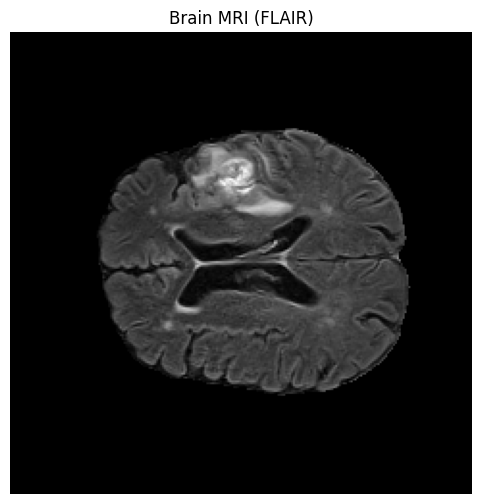

In [18]:
slice_index = 80

plt.figure(figsize=(6,6))
plt.imshow(flair[:,:,slice_index], cmap="gray")
plt.title("Brain MRI (FLAIR)")
plt.axis("off")
plt.show()

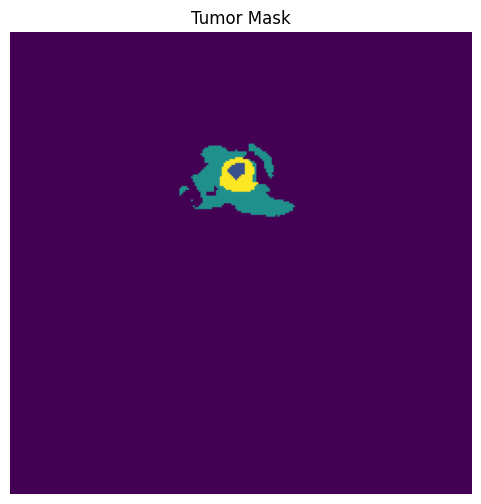

In [19]:
seg = nib.load(os.path.join(case_path, f"{case}_seg.nii.gz")).get_fdata()

plt.figure(figsize=(6,6))
plt.imshow(seg[:,:,slice_index])
plt.title("Tumor Mask")
plt.axis("off")
plt.show()

In [20]:
def normalize_image(img):
    img = (img - np.mean(img)) / np.std(img)
    return img

In [21]:
import cv2
IMG_SIZE = 128
X = []
Y = []
cases = os.listdir(data_path)

for case in cases:  # all cases
    case_path = os.path.join(data_path, case)
    
    try:
        flair = nib.load(os.path.join(case_path, f"{case}_flair.nii.gz")).get_fdata()
        seg   = nib.load(os.path.join(case_path, f"{case}_seg.nii.gz")).get_fdata()
    except Exception as e:
        print(f"Skipping {case}: {e}")
        continue

    # Only use middle 50 slices where tumor is most likely
    mid = flair.shape[2] // 2
    slice_range = range(max(0, mid-25), min(flair.shape[2], mid+25))

    for i in slice_range:
        mask = seg[:, :, i]
        mask = (mask > 0).astype(np.float32)

        if np.sum(mask) < 50:
            continue

        img = normalize_image(flair[:, :, i])
        img  = cv2.resize(img.astype(np.float32),  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0.5).astype(np.float32)

        X.append(img)
        Y.append(mask)

X = np.array(X)[..., np.newaxis]  # (N, 128, 128, 1)
Y = np.array(Y)[..., np.newaxis]  # (N, 128, 128, 1)
print("Dataset shape:", X.shape, Y.shape)

Skipping .DS_Store: No such file or no access: '/kaggle/working/brats/.DS_Store/.DS_Store_flair.nii.gz'
Dataset shape: (48627, 128, 128, 1) (48627, 128, 128, 1)


In [22]:
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print(X.shape, Y.shape)

(48627, 128, 128, 1, 1) (48627, 128, 128, 1, 1)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (38901, 128, 128, 1, 1)
Validation: (9726, 128, 128, 1, 1)


In [24]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)
    c1 = conv_block(inputs, 32);  p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);      p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);     p3 = MaxPooling2D()(c3)
    b  = conv_block(p3, 256)
    u1 = UpSampling2D()(b);  u1 = concatenate([u1, c3]); c4 = conv_block(u1, 128)
    u2 = UpSampling2D()(c4); u2 = concatenate([u2, c2]); c5 = conv_block(u2, 64)
    u3 = UpSampling2D()(c5); u3 = concatenate([u3, c1]); c6 = conv_block(u3, 32)
    outputs = Conv2D(1, 1, activation="sigmoid")(c6)
    return Model(inputs, outputs)


In [25]:
X_train_ = X_train[..., np.newaxis] if X_train.ndim == 3 else X_train
X_val_   = X_val[..., np.newaxis]   if X_val.ndim == 3   else X_val
Y_train_ = Y_train[..., np.newaxis] if Y_train.ndim == 3 else Y_train
Y_val_   = Y_val[..., np.newaxis]   if Y_val.ndim == 3   else Y_val

print("Shapes:", X_train_.shape, Y_train_.shape)  # (N, 128, 128, 1)

Shapes: (38901, 128, 128, 1, 1) (38901, 128, 128, 1, 1)


In [26]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(tf.reshape(y_true, [tf.shape(y_true)[0], -1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [tf.shape(y_pred)[0], -1]), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=1)
    union = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred, axis=1)
    return tf.reduce_mean((2. * intersection + smooth) / (union + smooth))

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [tf.shape(y_pred)[0], -1])
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true_f, y_pred_f))
    return bce + dice_loss(y_true, y_pred)

In [27]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, Activation
from tensorflow.keras.models import Model

In [28]:
tf.keras.backend.clear_session()  # clears corrupted graph
model = build_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=bce_dice_loss, metrics=[dice_coef])

history = model.fit(X_train_, Y_train_,
                    validation_data=(X_val_, Y_val_),
                    epochs=30, batch_size=16)


I0000 00:00:1772881576.328751      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772881576.335606      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1772881602.840441     115 service.cc:152] XLA service 0x7898c0002ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772881602.841603     115 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772881602.841609     115 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772881604.792985     115 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-07 11:06:49.032451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:06:49.310895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:06:50.332349: E external/local_xl

   1/2432 ━━━━━━━━━━━━━━━━━━━━ 18:12:50 27s/step - dice_coef: 0.0552 - loss: 1.9776

I0000 00:00:1772881620.414662     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2431/2432 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - dice_coef: 0.2906 - loss: 0.9189

2026-03-07 11:09:58.106604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:09:58.383832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:09:59.152308: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:09:59.448608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 11:09:59.712922: E external/local_xla/xla/stream_

2432/2432 ━━━━━━━━━━━━━━━━━━━━ 234s 85ms/step - dice_coef: 0.2907 - loss: 0.9187 - val_dice_coef: 0.7130 - val_loss: 0.3202
Epoch 2/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.7746 - loss: 0.2488 - val_dice_coef: 0.8177 - val_loss: 0.2076
Epoch 3/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.8612 - loss: 0.1578 - val_dice_coef: 0.8762 - val_loss: 0.1424
Epoch 4/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.8852 - loss: 0.1321 - val_dice_coef: 0.8830 - val_loss: 0.1369
Epoch 5/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.8953 - loss: 0.1207 - val_dice_coef: 0.8970 - val_loss: 0.1183
Epoch 6/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.9049 - loss: 0.1100 - val_dice_coef: 0.8926 - val_loss: 0.1261
Epoch 7/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_coef: 0.9073 - loss: 0.1070 - val_dice_coef: 0.9001 - val_loss: 0.1162
Epoch 8/30
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 192s 79ms/step - dice_co

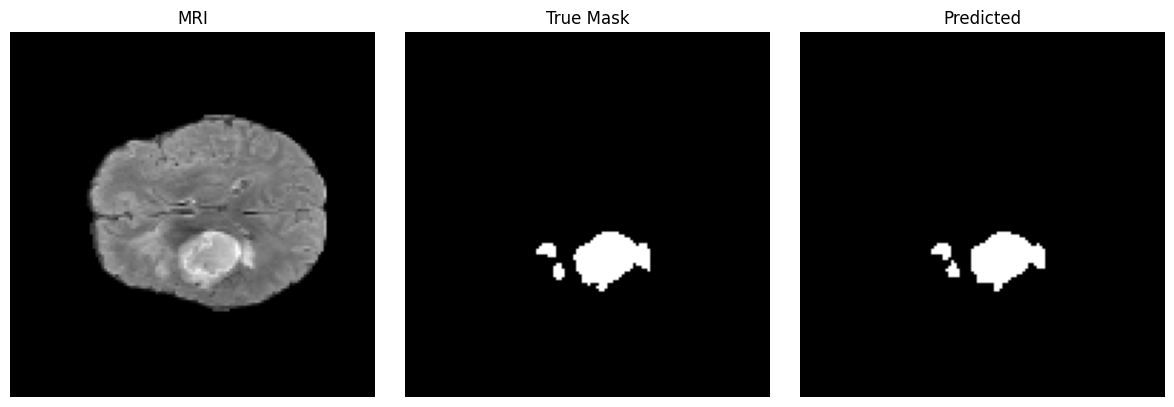

In [29]:
import matplotlib.pyplot as plt
idx = 10
sample = X_val_[idx:idx+1].astype(np.float32)
pred = model.predict(sample, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.title("MRI");       plt.imshow(X_val_[idx,:,:,0], cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("True Mask"); plt.imshow(Y_val_[idx,:,:,0], cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Predicted"); plt.imshow(pred[0,:,:,0] > 0.5, cmap="gray"); plt.axis("off")
plt.tight_layout()
plt.show()

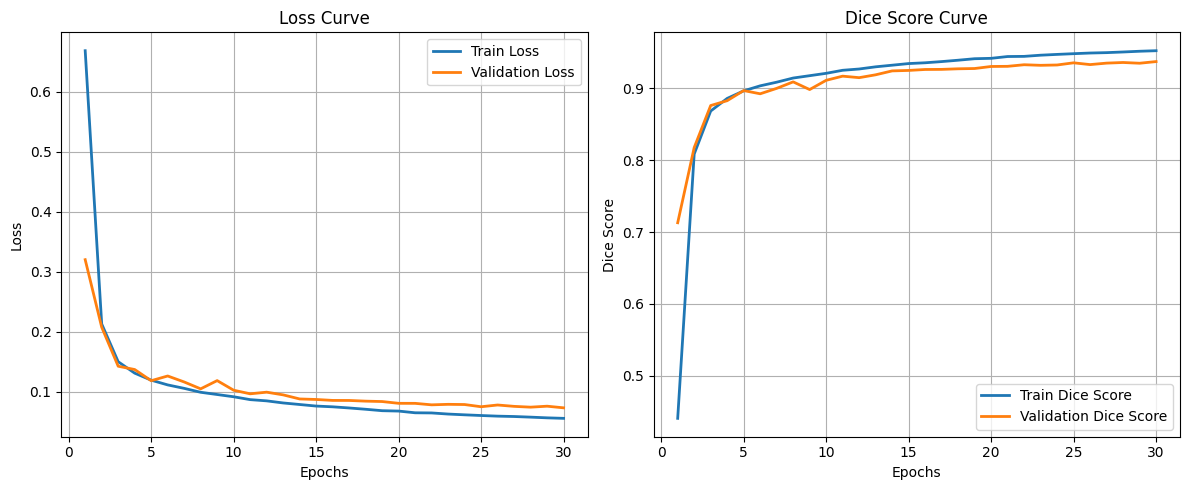

In [30]:
import matplotlib.pyplot as plt

# Extract history
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

train_dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12,5))

# ----- LOSS CURVE -----
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label="Train Loss", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ----- DICE SCORE CURVE -----
plt.subplot(1,2,2)
plt.plot(epochs, train_dice, label="Train Dice Score", linewidth=2)
plt.plot(epochs, val_dice, label="Validation Dice Score", linewidth=2)
plt.title("Dice Score Curve")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
model.save("/kaggle/working/neuvision_model.keras")
print("✅ Saved!")

✅ Saved!
